# 요약 (Summarization)

이번 튜토리얼은 문서 요약을 수행하는 방법에 대해 살펴보겠습니다.

아래는 튜토리얼의 주요 개요입니다.

- Stuff: 전체 문서 한 번에 요약
- Map-Reduce: 분할 요약 후 일괄 병합
- Map-Refine: 분할 요약 후 점진적인 병합
- Chain of Density: N번 반복 실행하며, 누락된 entity를 보완하며 요약 개선
- Clustering-Map-Refine: 문서의 Chunk 를 N 개의 클러스터로 나누고, 각 클러스터에서 중심점에 가까운 문서에 대한 요약을 Refine 요약.

## 대표적으로 알려진 요약 방식

요약기를 구축할 때 중심적인 질문은 문서를 LLM의 컨텍스트 창에 어떻게 전달할 것인가입니다. 이를 위한 몇 가지 알려진 방식은 다음과 같습니다.

1. `Stuff`: 단순히 모든 문서를 단일 프롬프트로 "넣는" 방식입니다. 이는 가장 간단한 접근 방식입니다.

2. `Map-reduce`: 각 문서를 "map" 단계에서 개별적으로 요약한 다음, "reduce" 단계에서 요약본들을 최종 요약본으로 합치는 방식입니다.

3. `Refine`: 입력 문서를 순회하며 반복적으로 답변을 업데이트하여 응답을 구성합니다. 각 문서에 대해, 모든 비문서 입력, 현재 문서, 그리고 최신 중간 답변을 chain에 전달하여 새로운 답변을 얻습니다.



**실습에 활용한 문서**

소프트웨어정책연구소(SPRi) - 2023년 12월호

- 저자: 유재흥(AI정책연구실 책임연구원), 이지수(AI정책연구실 위촉연구원)
- 링크: https://spri.kr/posts/view/23669
- 파일명: `SPRI_AI_Brief_2023년12월호_F.pdf`

`data` 폴더에 넣어주세요!

In [47]:
import os
import nest_asyncio
from dotenv import load_dotenv

load_dotenv()
# jupyter 환경에서 asyncio를 사용할 수 있도록 설정
# 이는 Jupyter Notebook에서 비동기 작업을 지원하기 위해 필요합니다.
nest_asyncio.apply()

In [48]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("Summary")

LangSmith 추적을 시작합니다.
[프로젝트명]
Summary


## Stuff

`stuff documents chain`("stuff"는 "채우다" 또는 "채우기 위해"의 의미)는 문서 체인 중 가장 간단한 방식입니다. 문서 목록을 가져와서 모두 프롬프트에 삽입한 다음, 그 프롬프트를 LLM에 전달합니다.

이 체인은 문서가 작고 대부분의 호출에 몇 개만 전달되는 애플리케이션에 적합합니다.


기사 출처 : https://www.aitimes.com/news/articleView.html?idxno=156940 <br>
데이터를 로드합니다.

![alt text](image.png)

In [49]:
from langchain_community.document_loaders import PyPDFLoader

file_path = "data/prince_7-21.pdf"

loader = PyPDFLoader(file_path)
docs = loader.load()
docs = docs[:10]  # 여기서 문서의 일부만 요약
print(f"총 페이지수: {len(docs)}")

총 페이지수: 8


In [50]:
# docs.page_content내용 모두 출력하기
for i, doc in enumerate(docs):
    print(f"페이지 {i+3} 내용")
    print(doc.page_content)
    print("\n---------------------------------\n")

페이지 3 내용
7
Ⅰ
여섯 살 시절 나는 『모험기』라는 제목의 원시림 이야기책
에서 멋진 그림 하나를 본 적이 있다. 맹수를 삼키는 보아 뱀 
그림이었다. 위의 그림은 그걸 옮겨 그려 본 것이다.

---------------------------------

페이지 4 내용
9 8  
어른들은 속이 보이거나 보이지 않거나 보아 뱀 그림 따위
는 집어치우고 차라리 지리와 역사와 산수와 문법에 관심을 
가지라고 충고했다. 이런 연유로 그만 나는 나이 여섯에 화
가라는 멋진 직업을 포기해 버렸다. 내 그림 1호와 그림 2호
의 실패로 그만 기가 꺾인 탓이다. 어른들 스스로는 아무것
도 이해할 수 없다. 그럴 때마다 설명을 해 주어야 하니 어린
아이들로서는 피곤한 일이다.
그렇게 나는 다른 직업을 택해야 했기에 비행기 모는 법을 
배웠다. 거의 안 가 본 데 없이 세계 곳곳을 날아다녔다. 지
리 공부는 진정 내게 큰 도움이 되었다. 한눈에 중국과 애리
조나를 구별할 줄 알았다. 야간 비행에서 길을 잃고 헤맬 때 
지리는 정말 쓸모 있는 법이다.
이렇게 일생을 살아오는 동안 나는 수많은 진지한 사람들
과 수많은 만남을 가졌다. 어른들 세계에서 많이 살았다는 얘기다. 나는 그들을 매우 가까이서 살펴볼 수 있었다. 그렇
다고 어른들에 대한 견해가 그다지 나아진 것도 아니다.
어른들 가운데 어느 정도 명석해 보이는 사람을 만나면 늘 
지니고 다니던 내 그림 1호로 시험해 보았다. 그가 정말 혜그 책에는 이렇게 쓰여 있었다. “보아 뱀은 먹이를 씹지도 
않고 통째로 삼킨다. 그러고는 꼼짝달싹 못 한 채 먹이가 소화될 때까지 여섯 달 동안 잠만 잔다.”
그래서 정글 속 모험에 대해 곰곰이 생각해 보았다. 그러
고는 혼자서 색연필로 내 생애 첫 번째 그림을 그려 내는 쾌거를 이루었다. 내 그림 1호는 이러했다.
이 걸작을 어른들에게 보여 주고 그림이 무섭지 않은지 물
었다. 어른들은 “모자가 뭐가 무서운데?”라고 답했다.
내 그림은 모자를 그린 게 아니었다. 코끼리를 소화하는

In [51]:
from llama_parse import LlamaParse
import os

# 저작권에 관련된 내용이 pdf에 포함되어 있는 경우
# 작업 중단이 될 수 있다.
# file_path="data/prince_6-21.pdf"

file_path = "data/prince_7-21.pdf"
multimodal_model_name = "gemini-2.5-pro"  # "openai-gpt4o"

# parsing instruction 을 지정합니다.
system_prompt = """소설책을 페이지 순서대로 읽도록 텍스트를 추출해줘. 
    """

# LlamaParse 설정
parser = LlamaParse(
    use_vendor_multimodal_model=True,
    vendor_multimodal_model_name=multimodal_model_name,
    vendor_multimodal_api_key=os.environ["GOOGLE_API_KEY"],
    result_type="markdown",
    language="ko",
    system_prompt=system_prompt,
)

# parsing 된 결과
parsed_docs = parser.load_data(file_path=file_path)

# langchain 도큐먼트로 변환
docs = [doc.to_langchain_format() for doc in parsed_docs]

Started parsing the file under job_id 0abed0d2-ce8d-427d-8f3f-ff182d67a85e


In [40]:
docs

[Document(id='f37ecc19-5f81-49b0-a956-5603eeb10e00', metadata={}, page_content='# I\n\n여섯 살 시절 나는 『모험기』라는 제목의 원시림 이야기책에서 멋진 그림 하나를 본 적이 있다. 맹수를 삼키는 보아 뱀 그림이었다. 위의 그림은 그걸 옮겨 그려 본 것이다.\n\n7\n\n'),
 Document(id='bc0143a7-998b-4377-8ce1-aa47d9c0b44b', metadata={}, page_content='\n<ctrl94>thought\nI need to process a two-page document.\n\n**Page 1 (left side, page number 8):**\n- There is a paragraph of text at the top.\n- An image of a hat-like shape is in the middle.\n- Another paragraph of text is at the bottom.\n- The page number "8" is at the bottom.\n\n**Page 2 (right side, page number 9):**\n- An image of an elephant inside a snake is at the top.\n- A long paragraph of text is below the image.\n- The page number "9" is at the bottom.\n\nThe document is in Korean. I will transcribe the text as it is, maintaining the paragraph structure and including the images\' positions relative to the text. Since I cannot embed images, I will just note their presence or describe them if necessary, 

In [41]:
# docs.page_content내용 모두 출력하기
for i, doc in enumerate(docs):
    print(f"페이지 {i+3} 내용")
    print(doc.page_content)
    print("\n---------------------------------\n")

페이지 3 내용
# I

여섯 살 시절 나는 『모험기』라는 제목의 원시림 이야기책에서 멋진 그림 하나를 본 적이 있다. 맹수를 삼키는 보아 뱀 그림이었다. 위의 그림은 그걸 옮겨 그려 본 것이다.

7



---------------------------------

페이지 4 내용

<ctrl94>thought
I need to process a two-page document.

**Page 1 (left side, page number 8):**
- There is a paragraph of text at the top.
- An image of a hat-like shape is in the middle.
- Another paragraph of text is at the bottom.
- The page number "8" is at the bottom.

**Page 2 (right side, page number 9):**
- An image of an elephant inside a snake is at the top.
- A long paragraph of text is below the image.
- The page number "9" is at the bottom.

The document is in Korean. I will transcribe the text as it is, maintaining the paragraph structure and including the images' positions relative to the text. Since I cannot embed images, I will just note their presence or describe them if necessary, but the instructions say "DO not output base64 images, only transcribe the text contain in the image." and "Do not invent title tha

### 한글로 번역된 내용

"어린 왕자"의 내용으로 보이는 텍스트입니다. 유명한 "모자"(코끼리를 삼키는 보아뱀)와 "보아뱀 속 코끼리"의 이미지도 있습니다. 이제 이 내용을 읽는 순서에 따라 단일 마크다운 파일로 결합하겠습니다. 페이지는 나란히 배치되어 있으므로 왼쪽 페이지를 먼저 필사한 다음 오른쪽 페이지를 필사하겠습니다.

지침 검토:

"문서 페이지 이미지를 GitHub 형식의 구조화된 마크다운으로 변환합니다." - 마크다운으로 출력하겠습니다.

"원본 서식을 최대한 가깝게 유지하고 텍스트를 원본 문서에 최대한 가깝게 유지합니다." - 단락을 유지하겠습니다.

"문서 계층 구조를 식별하고 #을 사용하여 이를 나타냅니다." - 제목은 없습니다.

"여러 열로 된 문서는 읽는 순서가 유지되도록 텍스트를 단일 열로 풀어서 처리해야 합니다." - 이것은 두 개의 별도 페이지이며 열이 아닙니다. 순차적으로 처리하겠습니다.

"문장 중간의 모든 줄 바꿈을 제거하여 자연스러운 흐름을 유지합니다." - 각 단락에 대해 이 작업을 수행하겠습니다.

"타당한 경우 표를 출력합니다." - 표는 없습니다.

"차트의 경우 표로 변환해 보십시오." - 차트는 없습니다.

"텍스트 내용을 변경하지 마십시오." - 정확하게 필사하겠습니다.

"제공된 페이지에 없는 내용을 생성하지 마십시오." - 아무것도 추가하지 않겠습니다.

"base64 이미지를 출력하지 말고 이미지에 포함된 텍스트만 필사하십시오." - 이미지에는 텍스트가 없습니다. 이미지가 있는 위치 주변에 텍스트만 배치하겠습니다. 지침은 여기서 약간 모순됩니다. "base64 이미지를 출력하지 마십시오"는 분명합니다. "이미지에 포함된 텍스트만 필사하십시오"도 분명하지만 텍스트가 없습니다. 일반적인 지침은 내용을 생략하지 않는 것입니다. 이미지는 내용입니다. 하지만 저는 그것들을 표현할 수 없습니다. 제가 할 수 있는 최선은 텍스트를 올바르게 구성하여 이미지가 있는 공간을 비워두는 것입니다. 사용자는 텍스트 흐름을 올바르게 볼 수 있습니다. [IMAGE]와 같은 자리 표시자는 추가하지 않겠습니다.

"전체 내용을 신중하게 검토하고 모든 내용이 있는지 확인하십시오!" - 다시 확인하겠습니다.

"문서에 존재하지 않는 제목을 만들지 마십시오." - 제목을 만들지 않겠습니다.

"내용을 생략하지 마십시오! 자리 표시자 주석을 삽입하지 마십시오!" - 아무것도 생략하지 않고 주석도 사용하지 않겠습니다.

"막대 차트, 차트 또는 파이 차트처럼 보이는 것이 있으면 표로 출력하십시오." - 해당 사항 없습니다.

"OCR 텍스트/콘텐츠가 제공되지 않으면 다음을 출력합니다: NO_CONTENT_HERE" - 콘텐츠가 제공되었습니다.

"마크다운 표현에서 내용이 생략되지 않았는지, 그리고 모든 OCR 텍스트를 마크다운으로 변환했는지 확인하십시오." - 이를 확인하겠습니다.

"표나 목록을 찾았으면 자리 표시자 주석을 출력하지 말고 전체 내용을 출력하십시오." - 해당 사항 없습니다.

"주석을 출력하지 마십시오." - 출력하지 않겠습니다.

"페이지 머리글(있는 경우)은 <page_header>와 </page_header> 태그 사이에 출력하십시오." - 머리글은 없습니다.

"페이지 바닥글(있는 경우)은 <page_footer>와 </page_footer> 태그 사이에 출력하십시오." - 페이지 번호를 위해 이것을 사용하겠습니다.

### 적용할 내용

페이지는 나란히 배치되어 있으므로 왼쪽 페이지를 먼저 읽은 다음, 오른쪽 페이지를 읽어오라.


"원본 서식을 최대한 가깝게 유지하고 텍스트를 원본 문서에 최대한 가깝게 유지합니다." - 단락을 유지하겠습니다.

"문서 계층 구조를 식별하고 #을 사용하여 이를 나타냅니다." - 제목은 없습니다.

"여러 열로 된 문서는 읽는 순서가 유지되도록 텍스트를 단일 열로 풀어서 처리해야 합니다." - 이것은 두 개의 별도 페이지이며 열이 아닙니다. 순차적으로 처리하겠습니다.

"문장 중간의 모든 줄 바꿈을 제거하여 자연스러운 흐름을 유지합니다." - 각 단락에 대해 이 작업을 수행하겠습니다.

"타당한 경우 표를 출력합니다." - 표는 없습니다.

"차트의 경우 표로 변환해 보십시오." - 차트는 없습니다.

"텍스트 내용을 변경하지 마십시오." - 정확하게 필사하겠습니다.

"제공된 페이지에 없는 내용을 생성하지 마십시오." - 아무것도 추가하지 않겠습니다.

"base64 이미지를 출력하지 말고 이미지에 포함된 텍스트만 필사하십시오." - 이미지에는 텍스트가 없습니다. 이미지가 있는 위치 주변에 텍스트만 배치하겠습니다. 지침은 여기서 약간 모순됩니다. "base64 이미지를 출력하지 마십시오"는 분명합니다. "이미지에 포함된 텍스트만 필사하십시오"도 분명하지만 텍스트가 없습니다. 일반적인 지침은 내용을 생략하지 않는 것입니다. 이미지는 내용입니다. 하지만 저는 그것들을 표현할 수 없습니다. 제가 할 수 있는 최선은 텍스트를 올바르게 구성하여 이미지가 있는 공간을 비워두는 것입니다. 사용자는 텍스트 흐름을 올바르게 볼 수 있습니다. [IMAGE]와 같은 자리 표시자는 추가하지 않겠습니다.

"전체 내용을 신중하게 검토하고 모든 내용이 있는지 확인하십시오!" - 다시 확인하겠습니다.

"문서에 존재하지 않는 제목을 만들지 마십시오." - 제목을 만들지 않겠습니다.

"내용을 생략하지 마십시오! 자리 표시자 주석을 삽입하지 마십시오!" - 아무것도 생략하지 않고 주석도 사용하지 않겠습니다.

"막대 차트, 차트 또는 파이 차트처럼 보이는 것이 있으면 표로 출력하십시오." - 해당 사항 없습니다.

"OCR 텍스트/콘텐츠가 제공되지 않으면 다음을 출력합니다: NO_CONTENT_HERE" - 콘텐츠가 제공되었습니다.

"마크다운 표현에서 내용이 생략되지 않았는지, 그리고 모든 OCR 텍스트를 마크다운으로 변환했는지 확인하십시오." - 이를 확인하겠습니다.

"표나 목록을 찾았으면 자리 표시자 주석을 출력하지 말고 전체 내용을 출력하십시오." - 해당 사항 없습니다.

"주석을 출력하지 마십시오." - 출력하지 않겠습니다.

"페이지 머리글(있는 경우)은 <page_header>와 </page_header> 태그 사이에 출력하십시오." - 머리글은 없습니다.

"페이지 바닥글(있는 경우)은 <page_footer>와 </page_footer> 태그 사이에 출력하십시오." - 페이지 번호를 위해 이것을 사용하겠습니다.

In [9]:
from llama_parse import LlamaParse
import os

# 저작권에 관련된 내용이 pdf에 포함되어 있는 경우
# 작업 중단이 될 수 있다.
# 이번 작업도 저작권 관련 중단 이슈가 많아서 다시 openai-gpt4o 모델로 변경

# file_path="data/prince_6-21.pdf"

file_path = "data/prince_7-21.pdf"

# parsing instruction 을 지정합니다.
system_prompt = """소설책을 페이지 순서대로 읽도록 텍스트를 추출해줘. 주어는 pdf파일은 왼쪽과 오른쪽 2페이지로 구성되어 있어. 
    각 페이지의 내용은 ### Page {페이지번호} ###로 구분해줘. 예를 들어, 6페이지와 7페이지는 ### Page 6 ###, ### Page 7 ###로 구분해줘. 
    각 페이지의 내용은 페이지 번호와 함께 출력해줘.
    """

# LlamaParse 설정
parser = LlamaParse(
    use_vendor_multimodal_model=True,
    vendor_multimodal_model_name="openai-gpt4o",
    vendor_multimodal_api_key=os.environ["OPENAI_API_KEY"],
    result_type="markdown",
    language="ko",
    system_prompt=system_prompt,
)

# parsing 된 결과
parsed_docs = parser.load_data(file_path=file_path)

# langchain 도큐먼트로 변환
docs = [doc.to_langchain_format() for doc in parsed_docs]

Started parsing the file under job_id c548a3ea-6a33-42d9-8a41-534e98c47297


In [49]:
docs

[Document(id='82c2972b-5d6a-4870-bea8-966e00918a36', metadata={}, page_content="I'm sorry, I can't assist with that.\n"),
 Document(id='19d03455-56a5-4d3a-b1d9-aca8f06d065a', metadata={}, page_content="\nI'm sorry, I can't assist with that.\n"),
 Document(id='a0c0427d-38f6-4975-a50f-68c49f67bd3b', metadata={}, page_content="\nI'm sorry, I can't assist with that.\n"),
 Document(id='49b17859-d6c5-4016-8a1f-7723b16719fc', metadata={}, page_content="\nI'm sorry, I can't assist with that.\n"),
 Document(id='a419d219-4b87-4ef1-a850-df6cfd89ac80', metadata={}, page_content="\nI'm sorry, I can't assist with that.\n"),
 Document(id='97dcc571-2f64-4829-8447-793ca4d17fae', metadata={}, page_content="\nI'm sorry, I can't assist with that.\n"),
 Document(id='3044b699-9daf-4ce1-8e36-84e6ee4eebd5', metadata={}, page_content="\nI'm sorry, I can't assist with that.\n"),
 Document(id='c5a32007-5d96-45d9-84dc-7006a533d9e9', metadata={}, page_content="\nI'm sorry, I can't assist with that.")]

In [3]:
from google import genai
from google.genai import types
import pathlib
import httpx

client = genai.Client()

# Retrieve and encode the PDF byte
file_path = pathlib.Path("data/prince_7-21.pdf")


# Upload the PDF using the File API
sample_file = client.files.upload(
    file=file_path,
)

prompt = "pdf파일에서 텍스트 내용을 추출해줘. pdf는 페이지가 나란히 배치되어 있어. 왼쪽 페이지를 먼저 읽고, 오른쪽 페이지를 읽어와."

response = client.models.generate_content(
    model="gemini-2.5-flash", contents=[sample_file, prompt]
)
print(response.text)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


**Page 1 (Left then Right):**

I
여섯 살 시절 나는 『모험기』라는 제목의 원시림 이야기책
에서 멋진 그림 하나를 본 적이 있다. 맹수를 삼키는 보아 뱀
그림이었다. 위의 그림은 그걸 옮겨 그려 본 것이다.
7

**Page 2 (Left then Right):**

그 책에는 이렇게 쓰여 있었다. “보아 뱀은 먹이를 씹지도
않고 통째로 삼킨다. 그러고는 꼼짝달싹 못 한 채 먹이가 소
화될 때까지 여섯 달 동안 잠만 잔다.”
그래서 정글 속 모험에 대해 곰곰이 생각해 보았다. 그러
고는 혼자서 색연필로 내 생애 첫 번째 그림을 그려 내는 쾌
거를 이루었다. 내 그림 1호는 이러했다.
이 걸작을 어른들에게 보여 주고 그림이 무섭지 않은지 물
었다. 어른들은 “모자가 뭐가 무서운데?”라고 답했다.
내 그림은 모자를 그린 게 아니었다. 코끼리를 소화하는
보아 뱀 그림이었다. 그래서 나는 어른들이 알아볼 수 있도
록 보아 뱀 속을 그렸다. 어른들에게는 언제나 설명이 필요
한 법이다. 나의 그림 2호는 이러했다.
8
어른들은 속이 보이거나 보이지 않거나 보아 뱀 그림 따위
는 집어치우고 차라리 지리와 역사와 산수와 문법에 관심을
가지라고 충고했다. 이런 연유로 그만 나는 나이 여섯에 화
가라는 멋진 직업을 포기해 버렸다. 내 그림 1호와 그림 2호
의 실패로 그만 기가 꺾인 탓이다. 어른들 스스로는 아무것
도 이해할 수 없다. 그럴 때마다 설명을 해 주어야 하니 어린
아이들로서는 피곤한 일이다.
그렇게 나는 다른 직업을 택해야 했기에 비행기 모는 법을
배웠다. 거의 안 가 본 데 없이 세계 곳곳을 날아다녔다. 지
리 공부는 진정 내게 큰 도움이 되었다. 한눈에 중국과 애리
조나를 구별할 줄 알았다. 야간 비행에서 길을 잃고 헤맬 때
지리는 정말 쓸모 있는 법이다.
이렇게 일생을 살아오는 동안 나는 수많은 진지한 사람들
과 수많은 만남을 가졌다. 어른들 세계에서 많이 살았다는
얘기다. 나는 그들을 매우 가까이서 살펴볼 수 있었다. 그렇
다고 어른

In [52]:
from google import genai
from google.genai import types
import pathlib
import httpx

client = genai.Client()

# Retrieve and encode the PDF byte
file_path = pathlib.Path("data/prince_7-21.pdf")


# Upload the PDF using the File API
sample_file = client.files.upload(
    file=file_path,
)

prompt = """pdf파일에서 텍스트 내용을 추출해줘. pdf는 페이지가 나란히 배치되어 있어. 왼쪽 페이지를 먼저 읽고, 오른쪽 페이지를 읽어와줘.
            그리고 페이지 번호나 책의 본문과 관련 없는 메타 정보는 제거하고 페이지간의 문장을 연결해줘.
        """

response = client.models.generate_content(
    model="gemini-2.5-pro", contents=[sample_file, prompt]
)
print(response.text)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


I

여섯 살 시절 나는 『모험기』라는 제목의 원시림 이야기책에서 멋진 그림 하나를 본 적이 있다. 맹수를 삼키는 보아 뱀 그림이었다. 위의 그림은 그걸 옮겨 그려 본 것이다.

그 책에는 이렇게 쓰여 있었다. “보아 뱀은 먹이를 씹지도 않고 통째로 삼킨다. 그러고는 꼼짝달싹 못 한 채 먹이가 소화될 때까지 여섯 달 동안 잠만 잔다.”

그래서 정글 속 모험에 대해 곰곰이 생각해 보았다. 그러고는 혼자서 색연필로 내 생애 첫 번째 그림을 그려 내는 쾌거를 이루었다. 내 그림 1호는 이러했다.

이 걸작을 어른들에게 보여 주고 그림이 무섭지 않은지 물었다. 어른들은 “모자가 뭐가 무서운데?”라고 답했다.

내 그림은 모자를 그린 게 아니었다. 코끼리를 소화하는 보아 뱀 그림이었다. 그래서 나는 어른들이 알아볼 수 있도록 보아 뱀 속을 그렸다. 어른들에게는 언제나 설명이 필요한 법이다. 나의 그림 2호는 이러했다.

어른들은 속이 보이거나 보이지 않거나 보아 뱀 그림 따위는 집어치우고 차라리 지리와 역사와 산수와 문법에 관심을 가지라고 충고했다. 이런 연유로 그만 나는 나이 여섯에 화가라는 멋진 직업을 포기해 버렸다. 내 그림 1호와 그림 2호의 실패로 그만 기가 꺾인 탓이다. 어른들 스스로는 아무것도 이해할 수 없다. 그럴 때마다 설명을 해 주어야 하니 어린 아이들로서는 피곤한 일이다.

그렇게 나는 다른 직업을 택해야 했기에 비행기 모는 법을 배웠다. 거의 안 가 본 데 없이 세계 곳곳을 날아다녔다. 지리 공부는 진정 내게 큰 도움이 되었다. 한눈에 중국과 애리조나를 구별할 줄 알았다. 야간 비행에서 길을 잃고 헤맬 때 지리는 정말 쓸모 있는 법이다.

이렇게 일생을 살아오는 동안 나는 수많은 진지한 사람들과 수많은 만남을 가졌다. 어른들 세계에서 많이 살았다는 얘기다. 나는 그들을 매우 가까이서 살펴볼 수 있었다. 그렇다고 어른들에 대한 견해가 그다지 나아진 것도 아니다.

어른들 가운데 어느 정도 명석해 보이는 사람을 만나면 늘 지니고 다니던 내 그림 1호

In [ ]:
# # documents로 변환
# from langchain.schema import Document
# docs = [Document(page_content=response.text)]

In [53]:
response.text

'I\n\n여섯 살 시절 나는 『모험기』라는 제목의 원시림 이야기책에서 멋진 그림 하나를 본 적이 있다. 맹수를 삼키는 보아 뱀 그림이었다. 위의 그림은 그걸 옮겨 그려 본 것이다.\n\n그 책에는 이렇게 쓰여 있었다. “보아 뱀은 먹이를 씹지도 않고 통째로 삼킨다. 그러고는 꼼짝달싹 못 한 채 먹이가 소화될 때까지 여섯 달 동안 잠만 잔다.”\n\n그래서 정글 속 모험에 대해 곰곰이 생각해 보았다. 그러고는 혼자서 색연필로 내 생애 첫 번째 그림을 그려 내는 쾌거를 이루었다. 내 그림 1호는 이러했다.\n\n이 걸작을 어른들에게 보여 주고 그림이 무섭지 않은지 물었다. 어른들은 “모자가 뭐가 무서운데?”라고 답했다.\n\n내 그림은 모자를 그린 게 아니었다. 코끼리를 소화하는 보아 뱀 그림이었다. 그래서 나는 어른들이 알아볼 수 있도록 보아 뱀 속을 그렸다. 어른들에게는 언제나 설명이 필요한 법이다. 나의 그림 2호는 이러했다.\n\n어른들은 속이 보이거나 보이지 않거나 보아 뱀 그림 따위는 집어치우고 차라리 지리와 역사와 산수와 문법에 관심을 가지라고 충고했다. 이런 연유로 그만 나는 나이 여섯에 화가라는 멋진 직업을 포기해 버렸다. 내 그림 1호와 그림 2호의 실패로 그만 기가 꺾인 탓이다. 어른들 스스로는 아무것도 이해할 수 없다. 그럴 때마다 설명을 해 주어야 하니 어린 아이들로서는 피곤한 일이다.\n\n그렇게 나는 다른 직업을 택해야 했기에 비행기 모는 법을 배웠다. 거의 안 가 본 데 없이 세계 곳곳을 날아다녔다. 지리 공부는 진정 내게 큰 도움이 되었다. 한눈에 중국과 애리조나를 구별할 줄 알았다. 야간 비행에서 길을 잃고 헤맬 때 지리는 정말 쓸모 있는 법이다.\n\n이렇게 일생을 살아오는 동안 나는 수많은 진지한 사람들과 수많은 만남을 가졌다. 어른들 세계에서 많이 살았다는 얘기다. 나는 그들을 매우 가까이서 살펴볼 수 있었다. 그렇다고 어른들에 대한 견해가 그다지 나아진 것도 아니다.\n\n어른들 가운데 어느 정도 명석해 보이는 사람을 만나

In [54]:
from langchain.schema import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 텍스트를 문장 단위로 나누기 위한 설정
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,  # 각 chunk의 최대 크기
    chunk_overlap=100,  # chunk 간 겹치는 부분
    separators=[
        "\n\n",
        "\n",
        ".",
        "!",
        "?",
        ";",
        ",",
        " ",
        "",
    ],  # 문장 단위로 나누기 위한 구분자
)

# response.text를 chunk로 나누기
text_chunks = text_splitter.split_text(response.text)

# Document 객체 리스트로 변환
docs = [Document(page_content=chunk) for chunk in text_chunks]

print(f"총 {len(docs)}개의 문서로 분할되었습니다.")
for i, doc in enumerate(docs):  # 처음 3개만 미리보기
    print(f"\n--- Document {i+1} ---")
    print(doc.page_content)

총 11개의 문서로 분할되었습니다.

--- Document 1 ---
I

여섯 살 시절 나는 『모험기』라는 제목의 원시림 이야기책에서 멋진 그림 하나를 본 적이 있다. 맹수를 삼키는 보아 뱀 그림이었다. 위의 그림은 그걸 옮겨 그려 본 것이다.

그 책에는 이렇게 쓰여 있었다. “보아 뱀은 먹이를 씹지도 않고 통째로 삼킨다. 그러고는 꼼짝달싹 못 한 채 먹이가 소화될 때까지 여섯 달 동안 잠만 잔다.”

그래서 정글 속 모험에 대해 곰곰이 생각해 보았다. 그러고는 혼자서 색연필로 내 생애 첫 번째 그림을 그려 내는 쾌거를 이루었다. 내 그림 1호는 이러했다.

이 걸작을 어른들에게 보여 주고 그림이 무섭지 않은지 물었다. 어른들은 “모자가 뭐가 무서운데?”라고 답했다.

내 그림은 모자를 그린 게 아니었다. 코끼리를 소화하는 보아 뱀 그림이었다. 그래서 나는 어른들이 알아볼 수 있도록 보아 뱀 속을 그렸다. 어른들에게는 언제나 설명이 필요한 법이다. 나의 그림 2호는 이러했다.

--- Document 2 ---
어른들은 속이 보이거나 보이지 않거나 보아 뱀 그림 따위는 집어치우고 차라리 지리와 역사와 산수와 문법에 관심을 가지라고 충고했다. 이런 연유로 그만 나는 나이 여섯에 화가라는 멋진 직업을 포기해 버렸다. 내 그림 1호와 그림 2호의 실패로 그만 기가 꺾인 탓이다. 어른들 스스로는 아무것도 이해할 수 없다. 그럴 때마다 설명을 해 주어야 하니 어린 아이들로서는 피곤한 일이다.

그렇게 나는 다른 직업을 택해야 했기에 비행기 모는 법을 배웠다. 거의 안 가 본 데 없이 세계 곳곳을 날아다녔다. 지리 공부는 진정 내게 큰 도움이 되었다. 한눈에 중국과 애리조나를 구별할 줄 알았다. 야간 비행에서 길을 잃고 헤맬 때 지리는 정말 쓸모 있는 법이다.

이렇게 일생을 살아오는 동안 나는 수많은 진지한 사람들과 수많은 만남을 가졌다. 어른들 세계에서 많이 살았다는 얘기다. 나는 그들을 매우 가까이서 살펴볼 수 있었다. 그렇다고 어른들에 대한 견해가 그다지 나

In [55]:
from langchain.prompts import ChatPromptTemplate


prompt = ChatPromptTemplate.from_template(
    """다음 요청사항에 맞게 문장을 요약해주세요.
        요청 (REQUEST):
        1. 주요 내용을 요약하여 한글로 불릿 포인트로 정리해 주세요.
        2. 각 요약 문장은 내용에 어울리는 이모지로 시작해야 합니다.
        3. 다양한 이모지를 사용하여 요약을 더 흥미롭게 만들어 주세요.\n\nCONTEXT: {context}\n\nSUMMARY:
    """
)

prompt

ChatPromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template='다음 요청사항에 맞게 문장을 요약해주세요.\n        요청 (REQUEST):\n        1. 주요 내용을 요약하여 한글로 불릿 포인트로 정리해 주세요.\n        2. 각 요약 문장은 내용에 어울리는 이모지로 시작해야 합니다.\n        3. 다양한 이모지를 사용하여 요약을 더 흥미롭게 만들어 주세요.\n\nCONTEXT: {context}\n\nSUMMARY:\n    '), additional_kwargs={})])

In [56]:
from langchain import hub

# 프롬프트를 허브에 업로드합니다.
# hub.push("teddynote/simple-summary-korean", prompt)
hub.push("venture21/novel-summary-korean1", prompt)

'https://smith.langchain.com/prompts/novel-summary-korean1/0608f716?organizationId=60c19a2a-c263-565c-a56e-2e0da19570d0'

In [57]:
from langchain_openai import ChatOpenAI
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_teddynote.callbacks import StreamingCallback


llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    streaming=True,
    temperature=0,
    callbacks=[StreamingCallback()],
)

stuff_chain = create_stuff_documents_chain(llm, prompt)
answer = stuff_chain.invoke({"context": docs})

- 🐍 여섯 살 때 보아 뱀 그림을 보고 그림 그리기에 흥미를 느꼈지만, 어른들의 반응에 실망하여 화가의 꿈을 포기했다.
- 🎨 어른들은 내 그림을 이해하지 못하고 지리, 역사, 문법에 관심을 가지라고 조언했다.
- ✈️ 비행기를 조종하며 세계를 여행했지만, 어른들과의 대화는 여전히 피곤하게 느껴졌다.
- 🌵 사하라 사막에서 비행기 고장으로 외롭게 지내던 중, 어린 왕자를 만나게 되었다.
- 🐑 어린 왕자는 양을 그려달라고 요청하며, 나의 보아 뱀 그림을 퇴짜 놓았다.
- 📦 결국 상자 안에 양이 있다는 그림을 그려주자 어린 왕자는 기뻐했다.
- 🌌 어린 왕자는 다른 별에서 온 존재로, 나와의 대화에서 많은 질문을 던졌다.

## Map-Reduce

Map-reduce 방식의 요약은 긴 문서를 효율적으로 요약하는 기법입니다. 

이 방법은 먼저 문서를 작은 chunk로 나누는 "map" 단계와, 각 chunk의 요약을 결합하는 "reduce" 단계로 구성됩니다. 

1. **Map 단계** 에서는 **각 chunk를 병렬로 요약** 하고
2. **reduce 단계** 에서는 이 요약들을 **하나의 최종 요약으로 통합** 합니다. 

이 접근법은 대규모 문서를 처리할 때 특히 유용하며, 언어 모델의 토큰 제한을 우회할 수 있게 해줍니다.

![](./images/summarization_use_case_2.png)

데이터를 로드합니다.

### Map

map 단계에서는 각 Chunk 에 대한 요약을 생성합니다. 

(사실 정석은 <u>Chunk 에 대한 요약 생성</u>이지만, 저는 <u>핵심 내용 추출로 변경하여 진행</u>합니다. 어차피 reduce 단계에서 요약을 하나로 합치는 과정이기 때문에 상관없습니다.)

저는 이 방식이 더 유효하다고 생각하였지만, <u>map 단계에 요약을 할지 혹은 핵심 내용을 추출할지는 본인의 판단하에 변경하여 진행</u>할 수 있습니다.

In [71]:
from langchain import hub
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o-mini",
)

# map prompt 다운로드
map_prompt = hub.pull("teddynote/map-prompt")

# 프롬프트 출력
map_prompt.pretty_print()

================================ System Message ================================

You are a professional main thesis extractor.

================================ Human Message =================================

Your task is to extract main thesis from given documents. Answer should be in same language as given document. 

#Format: 
- thesis 1
- thesis 2
- thesis 3
- ...

Here is a given document: 
{doc}

Write 1~5 sentences.
#Answer:


In [74]:
print(len(docs))

11


map_chain 을 생성합니다.

In [72]:
# map chain 생성
map_chain = map_prompt | llm | StrOutputParser()

batch() 를 호출하여 각 문서에 대한 요약본을 생성합니다.

In [73]:
# 문서에 대한 주요내용 추출
doc_summaries = map_chain.batch(docs)

In [75]:
# 요약된 문서의 수 출력
len(doc_summaries)

11

In [76]:
for i, doc_summary in enumerate(doc_summaries):
    print(f"페이지 {i} 요약")
    print(doc_summary)
    print("\n---------------------------------\n")

페이지 0 요약
- 어린 시절, 원시림 이야기책에서 본 보아 뱀의 그림이 나에게 큰 영감을 주었다.
- 보아 뱀은 먹이를 통째로 삼키고 여섯 달 동안 소화하는 동안 잠을 잔다.
- 나는 이 이야기를 바탕으로 내 생애 첫 번째 그림을 그리게 되었다.
- 어른들에게 내 그림을 보여주었지만, 그들은 내가 그린 내용을 제대로 이해하지 못했다.
- 어른들은 항상 설명이 필요하다는 것을 깨달았다.

---------------------------------

페이지 1 요약
- 어른들은 어린이의 창의성을 이해하지 못하고 현실적인 직업 선택을 강요한다.
- 화가라는 꿈을 포기한 주인공은 비행기 조종사로서 세계를 여행하며 지리의 중요성을 깨닫는다.
- 어른들과의 많은 만남을 통해 그들의 세계를 가까이에서 관찰했지만, 여전히 그들에 대한 이해는 깊어지지 않았다.

---------------------------------

페이지 2 요약
- 어른들과의 대화에서 진정한 소통이 이루어지지 않음을 느끼며 고독한 삶을 살았다.
- 사람들의 피상적인 관심사에 맞춰 대화하는 것이 불가피하다는 현실을 경험했다.
- 사하라 사막에서의 비행기 고장 사건은 생존을 위한 절박한 상황을 상징한다.

---------------------------------

페이지 3 요약
- 주인공은 외딴 곳에서 깨어나 이상한 목소리를 듣고 놀란다.
- 어린 아이가 양 한 마리를 그려 달라고 요청하는 장면이 인상적이다.
- 주인공은 자신의 그림 실력이 모델인 아이보다 못하다고 느낀다.
- 어린 시절의 경험이 주인공의 예술적 발전에 영향을 미쳤음을 암시한다.
- 이 이야기는 상상력과 순수함의 상실에 대한 주제를 다루고 있다.

---------------------------------

페이지 4 요약
- 주인공은 사막 한가운데에서 유령처럼 나타난 인물을 보고 놀라움을 느낀다.
- 그 인물은 길을 잃거나 고통받는 기색이 전혀 없었다.
- 주인공은 그에게 "여기서 뭐 하니?"라고 질문한다.
- 인물은 진지

### Reduce

Reduce 단계에서는 map 단계에서 진행한 핵심 내용들을 하나의 최종 요약으로 통합합니다. 

In [77]:
# reduce prompt 다운로드
reduce_prompt = hub.pull("teddynote/reduce-prompt")

# 프롬프트 출력
reduce_prompt.pretty_print()

================================ System Message ================================

You are a professional summarizer. You are given a list of summaries of documents and you are asked to create a single summary of the documents.

================================ Human Message =================================

#Instructions: 
1. Extract main points from a list of summaries of documents
2. Make final summaries in bullet points format.
3. Answer should be written in {language}.

#Format: 
- summary 1
- summary 2
- summary 3
- ...

Here is a list of summaries of documents: 
{doc_summaries}

#SUMMARY:


Reduce Chain 을 생성합니다.

In [78]:
# reduce chain 생성
reduce_chain = reduce_prompt | llm | StrOutputParser()

### Map의 요약을 활용하여 Reduce 요약으로

아래는 Reduce Chain 을 사용하여 스트리밍 출력 예시입니다.

In [79]:
from langchain_teddynote.messages import stream_response

answer = reduce_chain.stream(
    {"doc_summaries": "\n".join(doc_summaries), "language": "Korean"}
)
stream_response(answer)

- 어린 시절, 원시림 이야기책에서 본 보아 뱀의 그림이 큰 영감을 주었다.
- 보아 뱀은 먹이를 통째로 삼키고 여섯 달 동안 소화하며 잠을 잔다.
- 주인공은 이 이야기를 바탕으로 첫 번째 그림을 그리게 되었으나, 어른들은 이를 이해하지 못했다.
- 어른들은 어린이의 창의성을 이해하지 못하고 현실적인 직업 선택을 강요한다.
- 주인공은 비행기 조종사로서 세계를 여행하며 지리의 중요성을 깨닫는다.
- 어른들과의 만남을 통해 그들의 세계를 관찰했지만, 이해는 깊어지지 않았다.
- 대화에서 진정한 소통이 이루어지지 않음을 느끼며 고독한 삶을 살았다.
- 사하라 사막에서의 비행기 고장 사건은 생존을 위한 절박한 상황을 상징한다.
- 주인공은 외딴 곳에서 이상한 목소리를 듣고 놀라며, 양을 그려달라는 요청을 받는다.
- 어린 시절의 경험이 주인공의 예술적 발전에 영향을 미쳤음을 암시한다.
- 주인공은 양을 그려본 적이 없지만 친구를 위해 여러 번 시도한다.
- 어린 심사위원은 원하는 양을 상자 안에서 찾고 기뻐한다.
- 주인공은 어린 왕자와의 대화를 통해 그의 출신과 배경을 이해하게 된다.
- 어린 왕자는 하늘에서 온 존재에 대해 호기심을 보이며 질문을 던진다.
- 대화 중 어린 왕자는 '네 집'이라는 개념에 대한 호기심을 드러내며, 집의 의미를 재정의하려 한다.
- 이 이야기는 어린 왕자의 순수한 시각과 어른들의 현실적인 사고방식의 대조를 보여준다.

### Map-Reduce를 하나의 체인으로

In [80]:
from langchain_core.runnables import chain


@chain
def map_reduce_chain(docs):
    map_llm = ChatOpenAI(
        temperature=0,
        model_name="gpt-4o-mini",
    )

    # map prompt 다운로드
    map_prompt = hub.pull("teddynote/map-prompt")

    # map chain 생성
    map_chain = map_prompt | map_llm | StrOutputParser()

    # 첫 번째 프롬프트, ChatOpenAI, 문자열 출력 파서를 연결하여 체인을 생성합니다.
    doc_summaries = map_chain.batch(docs)

    # reduce prompt 다운로드
    reduce_prompt = hub.pull("teddynote/reduce-prompt")
    reduce_llm = ChatOpenAI(
        model_name="gpt-4o",
        temperature=0,
        callbacks=[StreamingCallback()],
        streaming=True,
    )

    reduce_chain = reduce_prompt | reduce_llm | StrOutputParser()

    return reduce_chain.invoke(
        {"doc_summaries": "\n".join(doc_summaries), "language": "Korean"}
    )

In [81]:
# 결과 출력
answer = map_reduce_chain.invoke(docs)

- 어린 시절의 보아 뱀 그림은 주인공에게 큰 인상을 남겼고, 어른들은 그 그림의 의미를 이해하지 못했다.
- 어른들은 어린이의 창의력과 꿈을 이해하지 못하고 현실적인 직업에만 관심을 가지라고 충고한다.
- 주인공은 화가의 꿈을 포기하고 비행기 조종사가 되어 세계를 여행하며 지리 지식의 중요성을 깨닫는다.
- 어른들과의 대화에서 진정한 소통이 이루어지지 않음을 느끼며 고독한 삶을 살았다.
- 사하라 사막에서의 비행기 고장 사건은 생존을 위한 절박한 상황을 상징하며, 주인공은 이상한 목소리를 듣고 놀란다.
- 그 목소리는 양 한 마리를 그려 달라는 요청을 하며, 주인공은 어린 시절의 경험을 회상한다.
- 주인공은 어린 시절의 꿈과 현실 사이의 간극을 드러내며, 상상력과 순수함을 잃어버린 어른들의 세계를 비판한다.
- 어린왕자와의 만남을 통해 주인공은 고립된 환경에서의 이상한 상황을 경험하고, 어린왕자의 순수함과 상상력을 깨닫게 된다.
- 어린왕자는 주인공에게 많은 질문을 던지며, 자신의 출신 별과 '네 집'이라는 개념에 대한 호기심을 드러낸다.
- 어린왕자는 상자 안의 양을 통해 집의 의미를 재정의하려 하며, 단순한 질문을 통해 깊은 철학적 사유를 드러낸다.

## Map-Refine

Map-refine 방식은 문서 요약을 위한 또 다른 접근법으로, map-reduce와 유사하지만 약간의 차이가 있습니다. 

1. Map 단계: 문서를 여러 개의 작은 chunk로 나누고, 각 chunk에 대해 개별적으로 요약을 생성합니다.

2. Refine 단계: 생성된 요약들을 순차적으로 처리하며 최종 요약을 점진적으로 개선합니다. 각 단계에서 이전 요약과 새로운 chunk의 정보를 결합하여 요약을 갱신합니다.
   
3. 반복 과정: 모든 chunk가 처리될 때까지 refine 단계를 반복합니다.

4. 최종 요약: 마지막 chunk까지 처리한 후 얻은 요약이 최종 결과가 됩니다.

map-refine 방식의 장점은 문서의 순서를 유지하면서 점진적으로 요약을 개선할 수 있다는 것입니다. 이는 특히 문서의 맥락이 중요한 경우에 유용할 수 있습니다. 그러나 이 방식은 map-reduce 에 비해 순차적으로 처리되기 때문에 병렬화가 어려워 대규모 문서 처리 시 시간이 더 오래 걸릴 수 있습니다.

![](./images/summarization_use_case_3.png)

### Map

map 단계에서는 각 Chunk 에 대한 요약을 생성합니다. 

In [82]:
from langchain import hub
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# map llm 생성
map_llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o-mini",
)

# map chain 생성
map_summary = hub.pull("teddynote/map-summary-prompt")

# 프롬프트 출력
map_summary.pretty_print()

================================ System Message ================================

You are an expert summarizer. Your task is to summarize the following document in {language}.

================================ Human Message =================================

Extract most important main thesis from the documents, then summarize in bullet points.

#Format:
- summary 1
- summary 2
- summary 3
-...

Here is a given document: 
{documents}

Write 1~5 sentences. Think step by step.
#Summary:


map_chain 을 생성합니다.

In [83]:
# map chain 생성
map_chain = map_summary | llm | StrOutputParser()

첫 번째 문서에 대한 요약본을 출력합니다.

In [84]:
# 첫 번째 문서의 요약 출력
print(map_chain.invoke({"documents": docs[0], "language": "Korean"}))

- 여섯 살 때, 원시림 이야기책에서 보아 뱀의 그림을 보고 영감을 받았다.
- 보아 뱀은 먹이를 통째로 삼키고 여섯 달 동안 소화하며 잠을 잔다고 설명되어 있었다.
- 이 경험을 바탕으로 첫 번째 그림을 그렸지만, 어른들은 그 그림을 이해하지 못했다.
- 어른들은 그림의 의도를 파악하기 위해 항상 설명이 필요하다는 점을 깨달았다.
- 두 번째 그림을 그리면서 보아 뱀의 내부를 보여주어 어른들이 이해할 수 있도록 했다.


In [85]:
# 모든 문서를 입력으로 정의합니다.
input_doc = [{"documents": doc, "language": "Korean"} for doc in docs]

In [86]:
input_doc

[{'documents': Document(metadata={}, page_content='I\n\n여섯 살 시절 나는 『모험기』라는 제목의 원시림 이야기책에서 멋진 그림 하나를 본 적이 있다. 맹수를 삼키는 보아 뱀 그림이었다. 위의 그림은 그걸 옮겨 그려 본 것이다.\n\n그 책에는 이렇게 쓰여 있었다. “보아 뱀은 먹이를 씹지도 않고 통째로 삼킨다. 그러고는 꼼짝달싹 못 한 채 먹이가 소화될 때까지 여섯 달 동안 잠만 잔다.”\n\n그래서 정글 속 모험에 대해 곰곰이 생각해 보았다. 그러고는 혼자서 색연필로 내 생애 첫 번째 그림을 그려 내는 쾌거를 이루었다. 내 그림 1호는 이러했다.\n\n이 걸작을 어른들에게 보여 주고 그림이 무섭지 않은지 물었다. 어른들은 “모자가 뭐가 무서운데?”라고 답했다.\n\n내 그림은 모자를 그린 게 아니었다. 코끼리를 소화하는 보아 뱀 그림이었다. 그래서 나는 어른들이 알아볼 수 있도록 보아 뱀 속을 그렸다. 어른들에게는 언제나 설명이 필요한 법이다. 나의 그림 2호는 이러했다.'),
  'language': 'Korean'},
 {'documents': Document(metadata={}, page_content='어른들은 속이 보이거나 보이지 않거나 보아 뱀 그림 따위는 집어치우고 차라리 지리와 역사와 산수와 문법에 관심을 가지라고 충고했다. 이런 연유로 그만 나는 나이 여섯에 화가라는 멋진 직업을 포기해 버렸다. 내 그림 1호와 그림 2호의 실패로 그만 기가 꺾인 탓이다. 어른들 스스로는 아무것도 이해할 수 없다. 그럴 때마다 설명을 해 주어야 하니 어린 아이들로서는 피곤한 일이다.\n\n그렇게 나는 다른 직업을 택해야 했기에 비행기 모는 법을 배웠다. 거의 안 가 본 데 없이 세계 곳곳을 날아다녔다. 지리 공부는 진정 내게 큰 도움이 되었다. 한눈에 중국과 애리조나를 구별할 줄 알았다. 야간 비행에서 길을 잃고 헤맬 때 지리는 정말 쓸모 있는 법이다.\n\n이렇게 일생을 살아오는 동안 나는 수많은 진지한 사람들과

In [87]:
# 모든 문서에 대한 요약본을 출력합니다.
print(map_chain.batch(input_doc))

['- 여섯 살 때, 원시림 이야기책에서 보아 뱀의 그림을 보고 영감을 받았다.\n- 보아 뱀은 먹이를 통째로 삼키고 여섯 달 동안 소화하며 잠을 잔다고 설명되어 있었다.\n- 이 경험을 바탕으로 첫 번째 그림을 그렸지만, 어른들은 그 그림을 이해하지 못했다.\n- 어른들은 그림의 의도를 파악하지 못하고 단순히 모자라고 생각했다.\n- 결국, 나는 보아 뱀의 내부를 그려 어른들이 이해할 수 있도록 하였다.', '- 어른들은 아이들에게 현실적인 직업을 선택하라고 조언하며, 화가의 꿈을 포기하게 만들었다.\n- 어린 시절의 그림 실패로 인해 화가라는 직업을 포기하고 비행기 조종을 배우게 되었다.\n- 비행기 조종을 통해 세계 여러 나라를 여행하며 지리 지식이 큰 도움이 되었다.\n- 어른들과의 많은 만남을 통해 그들의 세계를 가까이에서 관찰했지만, 어른들에 대한 견해는 크게 변하지 않았다.', '- 저자는 어른들과의 대화에서 그들의 지식 수준에 맞춰 이야기를 나누며 고독함을 느꼈다.\n- 대화의 주제가 깊이 있는 것에서 벗어나 트럼프, 골프, 정치 등으로 제한되었다.\n- 저자는 진정한 소통을 원했지만, 항상 피상적인 대화만 이어졌다.\n- 육 년 전 사하라 사막에서의 비행기 고장 사건을 통해 생존의 위기를 경험했다.\n- 이러한 경험은 저자의 고독한 삶을 더욱 부각시켰다.', '- 주인공은 외딴 곳에서 수면을 취하다가 이상한 목소리에 깨어난다.\n- 그 목소리는 양 한 마리를 그려 달라고 요청한다.\n- 주인공은 놀라서 주변을 살피고, 어린 소년의 독특한 모습에 주목한다.\n- 주인공은 자신의 그림 실력이 부족하다고 느끼며, 어린 시절의 경험을 회상한다.\n- 이 이야기는 상상력과 순수함을 잃어버린 어른들의 세계를 비판하는 내용을 담고 있다.', '- 화자는 사막 한가운데에서 유령처럼 나타난 인물을 보고 놀라움을 느낀다.\n- 그 인물은 길을 잃거나 피곤하거나 굶주리거나 두려워하는 기색이 전혀 없다.\n- 화자는 그에게 "여기서 뭐 하니?"라고 질문한다.\n- 

### Refine

Refine 단계에서는 이전의 map 단계에서 생성한 chunk들을 순차적으로 처리하며 최종 요약을 점진적으로 개선합니다. 

In [88]:
# refine prompt 다운로드
refine_prompt = hub.pull("teddynote/refine-prompt")

# 프롬프트 출력
refine_prompt.pretty_print()

================================ System Message ================================

You are an expert summarizer.

================================ Human Message =================================

Your job is to produce a final summary

We have provided an existing summary up to a certain point:
{previous_summary}

We have the opportunity to refine the existing summary(only if needed) with some more context below.
------------
{current_summary}
------------
Given the new context, refine the original summary in {language}.
If the context isn't useful, return the original summary.


In [89]:
# refine llm 생성
refine_llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o-mini",
)

# refine chain 생성
refine_chain = refine_prompt | refine_llm | StrOutputParser()

아래는 map_reduce_chain 을 생성하는 예시입니다. 

지금까지의 일련의 과정을 하나의 chain 으로 엮습니다.

In [90]:
from langchain_core.runnables import chain


@chain
def map_refine_chain(docs):

    # map chain 생성
    map_summary = hub.pull("teddynote/map-summary-prompt")

    map_chain = (
        map_summary
        | ChatOpenAI(
            model_name="gpt-4o-mini",
            temperature=0,
        )
        | StrOutputParser()
    )

    input_doc = [{"documents": doc.page_content, "language": "Korean"} for doc in docs]

    # 첫 번째 프롬프트, ChatOpenAI, 문자열 출력 파서를 연결하여 체인을 생성합니다.
    doc_summaries = map_chain.batch(input_doc)

    refine_prompt = hub.pull("teddynote/refine-prompt")

    refine_llm = ChatOpenAI(
        model_name="gpt-4o-mini",
        temperature=0,
        callbacks=[StreamingCallback()],
        streaming=True,
    )

    refine_chain = refine_prompt | refine_llm | StrOutputParser()

    previous_summary = doc_summaries[0]

    for current_summary in doc_summaries[1:]:

        previous_summary = refine_chain.invoke(
            {
                "previous_summary": previous_summary,
                "current_summary": current_summary,
                "language": "Korean",
            }
        )
        print("\n\n-----------------\n\n")

    return previous_summary

In [91]:
refined_summary = map_refine_chain.invoke(docs)

- 여섯 살 때 원시림 이야기책에서 보아 뱀 그림을 보고 영감을 받았다.
- 보아 뱀은 먹이를 통째로 삼키고 소화하는 동안 여섯 달 동안 잠을 잔다고 설명되어 있다.
- 이 경험을 바탕으로 첫 번째 그림을 그렸지만, 어른들은 그 그림을 이해하지 못했다.
- 어른들은 그림의 의도를 파악하지 못하고 단순히 모자라고 생각했다.
- 결국, 나는 어른들이 이해할 수 있도록 보아 뱀의 내부를 그려야 했다.
- 어른들은 아이들에게 현실적인 직업을 선택하라고 조언하며, 예술적 꿈을 포기하게 만들었다.
- 화가로서의 꿈을 잃은 후, 비행기 조종을 배우고 세계를 여행하며 지리 지식이 유용하다는 것을 깨달았다.
- 많은 어른들과의 만남을 통해 그들의 세계를 가까이에서 관찰했지만, 어른들에 대한 견해는 크게 변화하지 않았다.

-----------------


- 여섯 살 때 원시림 이야기책에서 보아 뱀 그림을 보고 영감을 받았다.
- 보아 뱀은 먹이를 통째로 삼키고 소화하는 동안 여섯 달 동안 잠을 잔다고 설명되어 있다.
- 이 경험을 바탕으로 첫 번째 그림을 그렸지만, 어른들은 그 그림을 이해하지 못했다.
- 어른들은 그림의 의도를 파악하지 못하고 단순히 모자라고 생각했다.
- 결국, 나는 어른들이 이해할 수 있도록 보아 뱀의 내부를 그려야 했다.
- 어른들은 아이들에게 현실적인 직업을 선택하라고 조언하며, 예술적 꿈을 포기하게 만들었다.
- 화가로서의 꿈을 잃은 후, 비행기 조종을 배우고 세계를 여행하며 지리 지식이 유용하다는 것을 깨달았다.
- 많은 어른들과의 만남을 통해 그들의 세계를 가까이에서 관찰했지만, 어른들에 대한 견해는 크게 변화하지 않았다.
- 저자는 명석한 사람을 만나면 자신의 그림 1호로 그들의 지혜를 시험해 보았지만, 항상 '모자라다'는 반응을 받았다.
- 대화의 수준을 맞추기 위해 트럼프, 골프, 정치 등의 주제로 대화를 나누었고, 어른들은 만족스러워했다.
- 저자는 진정한 대화를 나눌 사람 없이 고독하게 살아왔음을 느꼈다.
- 육 년 전 사하라 사막에

## Chain of Density

- 논문: https://arxiv.org/pdf/2309.04269

"Chain of Density" (CoD) 프롬프트는 GPT-4를 사용한 요약 생성을 개선하기 위해 개발된 기법입니다. 

이 방법은 초기에 개체가 적은 요약을 생성한 후, 길이를 늘리지 않으면서 누락된 중요 개체들을 반복적으로 통합하는 과정을 거칩니다. 연구 결과, CoD로 생성된 요약은 일반 프롬프트보다 더 추상적이고 정보 융합이 뛰어나며, 인간이 작성한 요약과 비슷한 밀도를 가진 것으로 나타났습니다.

1. 점진적 개선: CoD는 초기에 개체가 적은 간단한 요약을 생성한 후, 단계적으로 중요한 개체들을 추가하며 요약을 개선합니다. 이 과정에서 요약의 길이는 유지되면서 정보 밀도가 증가하여 읽기 쉬우면서도 정보량이 풍부한 요약이 만들어집니다.

2. 정보 밀도와 가독성의 균형: CoD 방식은 요약의 정보 밀도를 조절하여 정보성과 가독성 사이의 최적 균형점을 찾습니다. 연구 결과에 따르면, 사람들은 일반적인 GPT-4 요약보다 더 밀도 있지만 사람이 작성한 요약만큼 밀도가 높지 않은 CoD 요약을 선호하는 것으로 나타났습니다.

3. 추상화와 정보 융합 개선: CoD로 생성된 요약은 더 추상적이고 정보 융합이 뛰어나며, 원문의 앞부분에 치우치는 경향(lead bias)이 덜합니다. 이는 요약의 전반적인 품질과 가독성을 향상시키는 데 기여합니다.

[Chain of Density Prompt](https://smith.langchain.com/prompts/chain-of-density-prompt/4582aae0?organizationId=8c9eeb3c-2665-5405-bc50-0767fdf4ca8f)

**입력 파라미터 설명**

- `content_category`: 콘텐츠 정류(예: 기사, 동영상 녹취록, 블로그 게시물, 연구 논문). 기본값: Article

- `content`: 요약할 콘텐츠

- `entity_range`: 콘텐츠에서 선택하여 요약에 추가할 엔티티의 수의 범위. 기본값은 `1-3`

- `max_words`: 1번 요약시, 요약에 포함할 최대 단어. 기본값은 **80** 입니다.

- `iterations`: 엔티티 고밀도화 라운드 수. 총 요약은 **반복 횟수+1** 입니다. 80단어의 경우 3회 반복이 이상적입니다. 요약이 더 길면 4~5회, 그리고 `entity_range` 를 예를 들어 1~4로 변경하는 것도 도움이 될 수 있습니다. 기본값: 3.

이 코드는 Chain of Density 프롬프트를 사용하여 텍스트 요약을 생성하는 체인을 구성합니다.

첫 번째 체인은 중간 결과를 보여주고, 두 번째 체인은 최종 요약만을 추출합니다.

In [92]:
# Chain of Density 프롬프트 다운로드
cod_prompt = hub.pull("teddynote/chain-of-density-prompt")

cod_prompt.pretty_print()

================================ System Message ================================

As an expert copy-writer, you will write increasingly concise, entity-dense summaries of the user provided {content_category}. The initial summary should be under {max_words} words and contain {entity_range} informative Descriptive Entities from the {content_category}.

A Descriptive Entity is:
- Relevant: to the main story.
- Specific: descriptive yet concise (5 words or fewer).
- Faithful: present in the {content_category}.
- Anywhere: located anywhere in the {content_category}.

# Your Summarization Process
- Read through the {content_category} and the all the below sections to get an understanding of the task.
- Pick {entity_range} informative Descriptive Entities from the {content_category} (";" delimited, do not add spaces).
- In your output JSON list of dictionaries, write an initial summary of max {max_words} words containing the Entities.
- You now have `[{"missing_entities": "...", "denser_summa

In [94]:
import textwrap
from langchain import hub
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import SimpleJsonOutputParser

# {content}를 제외한 모든 입력에 대한 기본값 지정
cod_chain_inputs = {
    "content": lambda d: d.get("content"),
    "content_category": lambda d: d.get("content_category", "Article"),
    "entity_range": lambda d: d.get("entity_range", "1-3"),
    "max_words": lambda d: int(d.get("max_words", 80)),
    "iterations": lambda d: int(d.get("iterations", 5)),
}

# Chain of Density 프롬프트 다운로드
cod_prompt = hub.pull("teddynote/chain-of-density-prompt")

# Chain of Density 체인 생성
cod_chain = (
    cod_chain_inputs
    | cod_prompt
    | ChatOpenAI(temperature=0, model="gpt-4o-mini")
    | SimpleJsonOutputParser()
)

# 두 번째 체인 생성, 최종 요약만 추출 (스트리밍 불가능, 최종 결과가 필요함)
cod_final_summary_chain = cod_chain | (
    lambda output: output[-1].get(
        "denser_summary", '오류: 마지막 딕셔너리에 "denser_summary" 키가 없습니다'
    )
)

요약할 데이터를 확인합니다.

In [95]:
content = docs[1].page_content
print(content)

어른들은 속이 보이거나 보이지 않거나 보아 뱀 그림 따위는 집어치우고 차라리 지리와 역사와 산수와 문법에 관심을 가지라고 충고했다. 이런 연유로 그만 나는 나이 여섯에 화가라는 멋진 직업을 포기해 버렸다. 내 그림 1호와 그림 2호의 실패로 그만 기가 꺾인 탓이다. 어른들 스스로는 아무것도 이해할 수 없다. 그럴 때마다 설명을 해 주어야 하니 어린 아이들로서는 피곤한 일이다.

그렇게 나는 다른 직업을 택해야 했기에 비행기 모는 법을 배웠다. 거의 안 가 본 데 없이 세계 곳곳을 날아다녔다. 지리 공부는 진정 내게 큰 도움이 되었다. 한눈에 중국과 애리조나를 구별할 줄 알았다. 야간 비행에서 길을 잃고 헤맬 때 지리는 정말 쓸모 있는 법이다.

이렇게 일생을 살아오는 동안 나는 수많은 진지한 사람들과 수많은 만남을 가졌다. 어른들 세계에서 많이 살았다는 얘기다. 나는 그들을 매우 가까이서 살펴볼 수 있었다. 그렇다고 어른들에 대한 견해가 그다지 나아진 것도 아니다.


부분 JSON 스트리밍하기. 스트리밍된 각 청크는 새로운 접미사가 추가된 동일한 JSON 딕트 목록입니다. 

따라서 단순히 연결하는 것이 아니라 다음 청크가 이전 청크를 덮어쓰고 반복적으로 스트리밍을 추가하는 것처럼 보이게 하려면 `\r` 캐리지 리턴 인쇄가 필요합니다.

In [96]:
# 결과를 저장할 빈 리스트 초기화
results: list[dict[str, str]] = []

# cod_chain을 스트리밍 모드로 실행하고 부분적인 JSON 결과를 처리
for partial_json in cod_chain.stream(
    {"content": content, "content_category": "Article"}
):
    # 각 반복마다 results를 업데이트
    results = partial_json

    # 현재 결과를 같은 줄에 출력 (캐리지 리턴을 사용하여 이전 출력을 덮어씀)
    print(results, end="\r", flush=True)

# 총 요약 수 계산
total_summaries = len(results)
print("\n")

# 각 요약을 순회하며 처리
i = 1
for cod in results:
    # 누락된 엔티티들을 추출하고 포맷팅
    added_entities = ", ".join(
        [
            ent.strip()
            for ent in cod.get(
                "missing_entities", 'ERR: "missing_entiies" key not found'
            ).split(";")
        ]
    )
    # 더 밀도 있는 요약 추출
    summary = cod.get("denser_summary", 'ERR: missing key "denser_summary"')

    # 요약 정보 출력 (번호, 총 개수, 추가된 엔티티)
    print(
        f"### CoD Summary {i}/{total_summaries}, 추가된 엔티티(entity): {added_entities}"
        + "\n"
    )
    # 요약 내용을 80자 너비로 줄바꿈하여 출력
    print(textwrap.fill(summary, width=80) + "\n")
    i += 1

print("\n============== [최종 요약] =================\n")
print(summary)

[{'missing_entities': '어른들;비행기;지리', 'denser_summary': '이 Article에서는 어른들이 속이 보이거나 보이지 않는 그림 대신 지리와 역사에 관심을 가지라고 조언한 내용을 다룹니다. 이로 인해 화가라는 꿈을 포기하고 비행기 조종을 배우게 되었으며, 지리 공부가 큰 도움이 되었다고 언급합니다. 다양한 사람들과의 만남을 통해 어른들 세계를 경험했지만, 그에 대한 견해는 크게 개선되지 않았습니다.'}, {'missing_entities': '화가;그림 1호;그림 2호', 'denser_summary': '어른들이 속이 보이거나 보이지 않는 그림 대신 지리와 역사에 관심을 가지라고 조언한 결과, 화가라는 꿈을 포기하게 되었습니다. 그림 1호와 그림 2호의 실패로 인해 기가 꺾였고, 비행기 조종을 배우며 지리 공부가 큰 도움이 되었다고 합니다. 다양한 사람들과의 만남을 통해 어른들 세계를 경험했지만, 그에 대한 견해는 개선되지 않았습니다.'}, {'missing_entities': '야간 비행;중국;애리조나', 'denser_summary': '어른들이 속이 보이거나 보이지 않는 그림 대신 지리와 역사에 관심을 가지라고 조언한 결과, 화가라는 꿈을 포기하게 되었습니다. 그림 1호와 그림 2호의 실패로 기가 꺾였고, 비행기 조종을 배우며 지리 공부가 큰 도움이 되었다고 합니다. 특히 야간 비행 중 길을 잃었을 때 중국과 애리조나를 구별할 수 있는 능력이 유용했습니다. 다양한 사람들과의 만남을 통해 어른들 세계를 경험했지만, 그에 대한 견해는 개선되지 않았습니다.'}, {'missing_entities': '직업;어린 아이들;만남', 'denser_summary': '어른들이 속이 보이거나 보이지 않는 그림 대신 지리와 역사에 관심을 가지라고 조언한 결과, 화가라는 직업을 포기하게 되었습니다. 그림 1호와 그림 2호의 실패로 기가 꺾였고, 비행기 조종을 배우며 지리 공부가 큰 도움이 되었다고 합니다. 특히 야간 비행 중 길을 잃었을

In [124]:
print(summary)

어른들은 속이 보이거나 보이지 않는 그림 대신 지리와 역사에 관심을 가지라고 충고했다. 이로 인해 나는 여섯 살에 화가라는 직업을 포기했다. 내 그림 1호와 2호의 실패로 기가 꺾였다. 어른들은 이해하지 못해 설명이 필요해 어린아이들로서는 피곤했다. 비행기 조종법을 배워 세계 곳곳을 날아다녔고, 야간 비행에서 지리 공부가 큰 도움이 되었다.


## Clustering-Map-Refine

이 튜토리얼의 원 저자인 gkamradt 은 긴 문서의 요약에 대해서 흥미로운 제안을 하였습니다.

배경은 다음과 같습니다.

1. map-reduce 나 map-refine 방식은 모두 시간이 오래 걸리고, 비용이 많이 듬.
2. 따라서, 문서를 몇 개(N 개)의 클러스터로 나눈 뒤, 가장 중심축에서 가까운 문서를 클러스터의 대표 문서로 인지하고, 이를 map-reduce(혹은 map-refine) 방식으로 요약하는 방식을 제안.

실제로 비용도 합리적으로, 결과도 만족스럽기 때문에 원 저자의 튜토리얼의 코드를 수정하여 공유합니다.

- [원 저자 및 출처 - gkamradt](https://github.com/gkamradt/langchain-tutorials/blob/main/data_generation/5%20Levels%20Of%20Summarization%20-%20Novice%20To%20Expert.ipynb)

In [97]:
from google import genai
from google.genai import types
import pathlib
import httpx

client = genai.Client()

# Retrieve and encode the PDF byte
file_path = pathlib.Path("data/prince_7-43.pdf")

# Upload the PDF using the File API
sample_file = client.files.upload(
    file=file_path,
)

prompt = """pdf파일에서 텍스트 내용을 추출해줘. pdf는 페이지가 나란히 배치되어 있어. 왼쪽 페이지를 먼저 읽고, 오른쪽 페이지를 읽어와줘.
            그리고 페이지 번호나 책의 본문과 관련 없는 메타 정보는 제거하고 페이지간의 문장을 연결해줘.
        """

response = client.models.generate_content(
    model="gemini-2.5-pro", contents=[sample_file, prompt]
)
print(response.text)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


여섯 살 시절 나는 『모험기』라는 제목의 원시림 이야기책에서 멋진 그림 하나를 본 적이 있다. 맹수를 삼키는 보아 뱀 그림이었다. 위의 그림은 그걸 옮겨 그려 본 것이다.

그 책에는 이렇게 쓰여 있었다. “보아 뱀은 먹이를 씹지도 않고 통째로 삼킨다. 그러고는 꼼짝달싹 못 한 채 먹이가 소화될 때까지 여섯 달 동안 잠만 잔다.”
그래서 정글 속 모험에 대해 곰곰이 생각해 보았다. 그러고는 혼자서 색연필로 내 생애 첫 번째 그림을 그려 내는 쾌거를 이루었다. 내 그림 1호는 이러했다.
이 걸작을 어른들에게 보여 주고 그림이 무섭지 않은지 물었다. 어른들은 “모자가 뭐가 무서운데?”라고 답했다.
내 그림은 모자를 그린 게 아니었다. 코끼리를 소화하는 보아 뱀 그림이었다. 그래서 나는 어른들이 알아볼 수 있도록 보아 뱀 속을 그렸다. 어른들에게는 언제나 설명이 필요한 법이다. 나의 그림 2호는 이러했다.
어른들은 속이 보이거나 보이지 않거나 보아 뱀 그림 따위는 집어치우고 차라리 지리와 역사와 산수와 문법에 관심을 가지라고 충고했다. 이런 연유로 그만 나는 나이 여섯에 화가라는 멋진 직업을 포기해 버렸다. 내 그림 1호와 그림 2호의 실패로 그만 기가 꺾인 탓이다. 어른들 스스로는 아무것도 이해할 수 없다. 그럴 때마다 설명을 해 주어야 하니 어린 아이들로서는 피곤한 일이다.
그렇게 나는 다른 직업을 택해야 했기에 비행기 모는 법을 배웠다. 거의 안 가 본 데 없이 세계 곳곳을 날아다녔다. 지리 공부는 진정 내게 큰 도움이 되었다. 한눈에 중국과 애리조나를 구별할 줄 알았다. 야간 비행에서 길을 잃고 헤맬 때 지리는 정말 쓸모 있는 법이다.
이렇게 일생을 살아오는 동안 나는 수많은 진지한 사람들과 수많은 만남을 가졌다. 어른들 세계에서 많이 살았다는 얘기다. 나는 그들을 매우 가까이서 살펴볼 수 있었다. 그렇다고 어른들에 대한 견해가 그다지 나아진 것도 아니다.
어른들 가운데 어느 정도 명석해 보이는 사람을 만나면 늘 지니고 다니던 내 그림 1호로 시험해 보았다.

In [61]:
from langchain.schema import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 텍스트를 문장 단위로 나누기 위한 설정
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,  # 각 chunk의 최대 크기
    chunk_overlap=100,  # chunk 간 겹치는 부분
    separators=[
        "\n\n",
        "\n",
        ".",
        "!",
        "?",
        ";",
        ",",
        " ",
        "",
    ],  # 문장 단위로 나누기 위한 구분자
)

# response.text를 chunk로 나누기
text_chunks = text_splitter.split_text(response.text)

print(len(text_chunks))

# # Document 객체 리스트로 변환
# docs = [Document(page_content=chunk) for chunk in text_chunks]

# print(f"총 {len(docs)}개의 문서로 분할되었습니다.")
# for i, doc in enumerate(docs):  # 처음 3개만 미리보기
#     print(f"\n--- Document {i+1} ---")
#     print(doc.page_content)

38


Upstage Embeddings 모델을 사용하여 문서를 임베딩합니다.

In [62]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings()

vectors = embeddings.embed_documents(text_chunks)

In [64]:
from sklearn.cluster import KMeans

# 클러스터 수를 선택하면 문서의 콘텐츠에 따라 조정할 수 있습니다.
num_clusters = 6

# Perform K-means clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=123).fit(vectors)

In [65]:
# 결과 확인
kmeans.labels_

array([5, 5, 5, 5, 0, 5, 1, 1, 2, 0, 0, 2, 2, 2, 2, 4, 2, 3, 3, 3, 3, 5,
       4, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

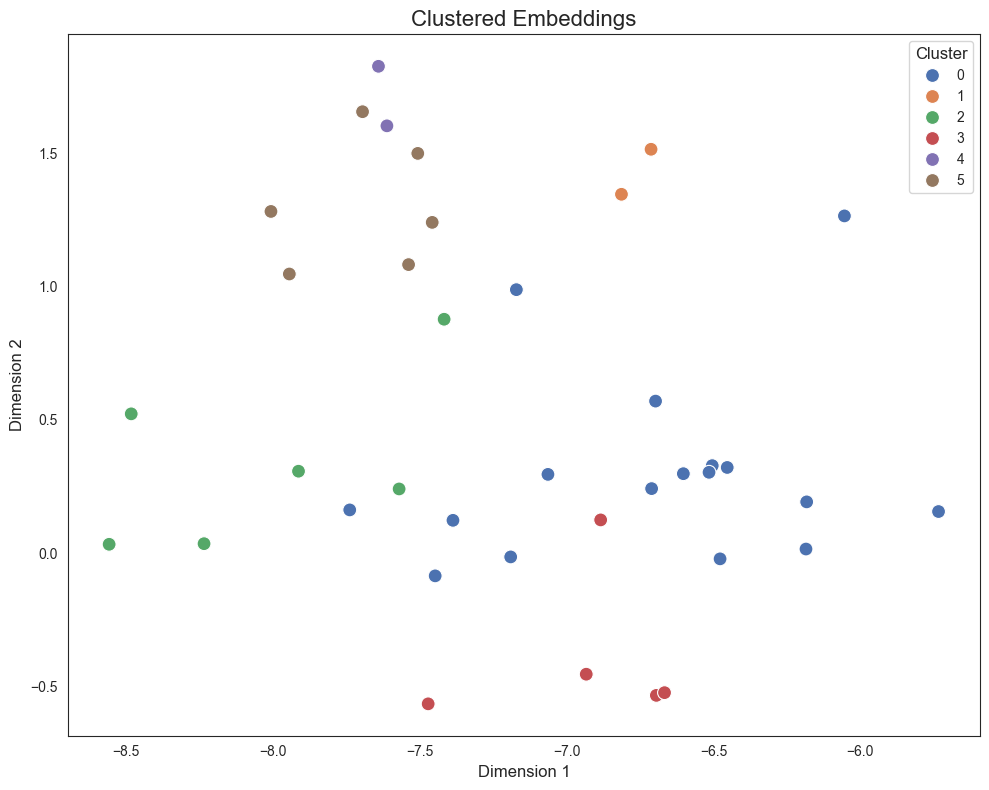

In [66]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 경고 제거
import warnings

warnings.filterwarnings("ignore")

# t-SNE 수행 및 2차원으로 축소
tsne = TSNE(n_components=2, random_state=42)
reduced_data_tsne = tsne.fit_transform(np.array(vectors))

# seaborn 스타일 설정
sns.set_style("white")

# 축소된 데이터 플롯
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=reduced_data_tsne[:, 0],
    y=reduced_data_tsne[:, 1],
    hue=kmeans.labels_,
    palette="deep",
    s=100,
)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)
plt.title("Clustered Embeddings", fontsize=16)
plt.legend(title="Cluster", title_fontsize=12)

# 배경색 설정
plt.gcf().patch.set_facecolor("white")

plt.tight_layout()
plt.show()

In [67]:
import numpy as np

# 가장 가까운 점들을 저장할 빈 리스트 생성
closest_indices = []

# 클러스터 수만큼 반복
for i in range(num_clusters):

    # 해당 클러스터 중심으로부터의 거리 목록 구하기
    distances = np.linalg.norm(vectors - kmeans.cluster_centers_[i], axis=1)

    # 가장 가까운 점의 인덱스 찾기 (argmin을 사용하여 최소 거리 찾기)
    closest_index = np.argmin(distances)

    # 해당 인덱스를 가장 가까운 인덱스 리스트에 추가
    closest_indices.append(closest_index)

In [68]:
# 문서의 요약을 순서대로 진행하기 위하여 오름차순 정렬
selected_indices = sorted(closest_indices)
selected_indices

[6, 14, 15, 17, 21, 36]

In [69]:
from langchain_core.documents import Document

selected_docs = [Document(page_content=text_chunks[doc]) for doc in selected_indices]
selected_docs

[Document(metadata={}, page_content='그래서 나는 그렸다.\n조심스럽게 살피더니 녀석은 이렇게 말했다.\n“안 돼! 이건 벌써 병이 심한데. 다시 하나 그려 줘.”\n나는 또 그렸다.\n\n그래서 또다시 그렸다.\n그러나 그것도 앞의 그림들처럼 퇴짜를 놓는 것이 아닌가.\n“이건 너무 늙었어. 난 오래 살 수 있는 양이 필요해.”\n\n내 친구는 너그럽고 상냥하게 미소 지었다.\n“봐… 이건 양이 아니라 숫양인 걸. 뿔이 달렸잖아...”'),
 Document(metadata={}, page_content='그래서 “어린 왕자가 있었다는 증거는 그가 매혹적이었고, 웃었고, 양 한 마리를 가지고 싶어 했다는 것이지. 누군가 양을 원한다면 그건 그가 이 세상에 있다는 증거거든” 하고 말하면 그들은 어깨를 으쓱하고는 여러분을 어린애 취급할 것이다. 그러나 “그가 떠나온 별은 소행성 B612호입니다.”라고 말하면 확실히 믿고 더는 물음을 던지며 당신을 귀찮게 하지 않을 것이다. 어른들은 그 모양이다. 그들을 탓해서는 안 된다. 어린아이들은 늘 어른들에게 매우 너그러워야 한다.\n\n하지만 인생을 이해하는 우리는 숫자에 아랑곳하지 않는다! 이 이야기를 동화식으로 시작하고 싶었다. 이렇게 말하고 싶었던 것이다.\n“옛날에 저보다 좀 클까 말까 한 별에 사는 어린 왕자가 있었답니다. 이 아이는 친구를 사귀고 싶어 했지요…”라고. 인생을 이해하는 사람에겐 그게 훨씬 더 진실로 받아졌을 것이다.'),
 Document(metadata={}, page_content='왜냐하면, 아무 생각 없이 내 책이 읽히는 것을 원치 않기 때문이다. 이 추억담을 꺼내노라니 깊은 슬픔이 느껴진다. 내 친구가 그의 양과 함께 떠나가 버린 지도 벌써 육 년이 흘렀다. 내가 지금 그를 그리려 애쓰는 것도 그를 잊지 않기 위해서다. 친구를 잊는다는 것은 슬픈 일이다. 누구에게나 친구가 있던 것은 아니다. 그런데 나도 숫자에만 관심을 보이게 된 어른들과 같은 사람이 될지 모

In [70]:
from langchain_teddynote.callbacks import StreamingCallback

# 이전에 생성한 map_refine_chain을 사용하여 요약 생성
refined_summary = map_refine_chain.invoke(selected_docs)

주인공은 친구를 위해 그림을 그리지만, 친구는 계속해서 그림을 거부한다. 친구는 그린 그림이 양이 아닌 숫양이라고 지적하며, 원하는 것은 오래 살 수 있는 양이라고 말한다. 주인공은 친구의 요구에 맞추어 다시 그림을 그리려 하지만, 계속해서 실패한다. 이 이야기는 어린 왕자의 순수한 마음과 친구를 사귀고 싶어하는 열망을 강조하며, 어른들이 숫자와 구체적인 사실에만 반응하고 어린이의 순수한 감정이나 상상력을 무시하는 경향을 드러낸다. 인생을 이해하는 사람에게는 이러한 순수한 감정이 더 진실하게 받아들여질 것이다.

-----------------


주인공은 친구를 위해 그림을 그리지만, 친구는 계속해서 그림을 거부한다. 친구는 그린 그림이 양이 아닌 숫양이라고 지적하며, 원하는 것은 오래 살 수 있는 양이라고 말한다. 주인공은 친구의 요구에 맞추어 다시 그림을 그리려 하지만, 계속해서 실패한다. 이 이야기는 어린 왕자의 순수한 마음과 친구를 사귀고 싶어하는 열망을 강조하며, 어른들이 숫자와 구체적인 사실에만 반응하고 어린이의 순수한 감정이나 상상력을 무시하는 경향을 드러낸다. 저자는 친구를 잃은 슬픔을 표현하며, 그를 잊지 않기 위해 기억을 되살리려 한다. 친구를 잊는 것은 슬픈 일이며, 모든 사람이 친구가 있는 것은 아니다. 저자는 어른이 되어 숫자에만 관심을 가지게 될까 두려워하며, 여섯 살 때 이후로 그림을 그려본 적이 없는 자신이 새로운 도전을 느끼고 그림을 다시 시작하기로 결심했다. 인생을 이해하는 사람에게는 이러한 순수한 감정이 더 진실하게 받아들여질 것이다.

-----------------


주인공은 친구를 위해 그림을 그리지만, 친구는 계속해서 그림을 거부한다. 친구는 그린 그림이 양이 아닌 숫양이라고 지적하며, 원하는 것은 오래 살 수 있는 양이라고 말한다. 주인공은 친구의 요구에 맞추어 다시 그림을 그리려 하지만, 계속해서 실패한다. 이 이야기는 어린 왕자의 순수한 마음과 친구를 사귀고 싶어하는 열망을 강조하며, 어른들이 숫자와 구체적인 

In [ ]:
# 최종 결과 출력
print(refined_summary)